# DATA DOWNLOAD AND PARAMETER ESTIMATION
We use 2025 data to decide on a monthly investement.

In [26]:
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# 1. Download data
# -----------------------------
start_date = "2025-01-01"
end_date = "2025-12-31"

A = "XOM"
B = "NVDA"

xom = yf.download(A, start=start_date, end=end_date)
nvda = yf.download(B, start=start_date, end=end_date)

# -----------------------------
# 2. Compute log-returns
# -----------------------------
xom["LogReturn"] = np.log(xom["Close"] / xom["Close"].shift(1))
nvda["LogReturn"] = np.log(nvda["Close"] / nvda["Close"].shift(1))

# -----------------------------
# 3. Align dates and keep only common observations
# -----------------------------
data = pd.concat(
    [xom["LogReturn"], nvda["LogReturn"]],
    axis=1,
    join="inner"
)
data.columns = [A, B]
data = data.dropna()



/tmp/ipykernel_22148/2485030466.py:15: FutureWarning: YF.download() has changed argument auto_adjust default to True
  xom = yf.download(A, start=start_date, end=end_date)
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_22148/2485030466.py:16: FutureWarning: YF.download() has changed argument auto_adjust default to True
  nvda = yf.download(B, start=start_date, end=end_date)
[*********************100%***********************]  1 of 1 completed


## COMPUTING SUMMARY STATISTICS AND MINIMUM VARIANCE

In [27]:

# -----------------------------
# 4. Compute daily statistics from aligned data
# -----------------------------
mean_A_daily = data[A].mean()
var_A_daily = data[A].var()
std_A_daily = data[A].std()

mean_B_daily = data[B].mean()
var_B_daily = data[B].var()
std_B_daily = data[B].std()

corr_AB = data[A].corr(data[B])
cov_AB_daily = data[A].cov(data[B])

# -----------------------------
# 5. Convert to monthly values (21 trading days)
# -----------------------------
mean_A_monthly = mean_A_daily * 21
var_A_monthly = var_A_daily * 21
std_A_monthly = std_A_daily * np.sqrt(21)

mean_B_monthly = mean_B_daily * 21
var_B_monthly = var_B_daily * 21
std_B_monthly = std_B_daily * np.sqrt(21)

cov_AB_monthly = cov_AB_daily * 21
# equivalent to: corr_AB * std_A_monthly * std_B_monthly

# -----------------------------
# 6. Minimum variance portfolio
# A = XOM, B = NVDA
# -----------------------------
w_A_min_var = (var_B_monthly - cov_AB_monthly) / (
    var_A_monthly + var_B_monthly - 2 * cov_AB_monthly
)
w_B_min_var = 1 - w_A_min_var

expected_return_min_var = (
    w_A_min_var * mean_A_monthly + w_B_min_var * mean_B_monthly
)

min_var_value = (
    w_A_min_var**2 * var_A_monthly
    + w_B_min_var**2 * var_B_monthly
    + 2 * w_A_min_var * w_B_min_var * cov_AB_monthly
)
std_min_var = np.sqrt(min_var_value)


# COMPUTING THE TANGENCY PORTFOLIO
We consider a risk-free investment which in 31-days will give a 2% log-return.

In [28]:

# -----------------------------
# 7. Tangency portfolio
# -----------------------------
R_f = 0.01  # monthly risk-free rate if that is your convention

V1 = mean_A_monthly - R_f
V2 = mean_B_monthly - R_f

w_A_tangency = (V1 * var_B_monthly - V2 * cov_AB_monthly) / (
    V1 * var_B_monthly + V2 * var_A_monthly - (V1 + V2) * cov_AB_monthly
)
w_B_tangency = 1 - w_A_tangency

expected_return_tangency = (
    w_A_tangency * mean_A_monthly + w_B_tangency * mean_B_monthly
)

variance_tangency = (
    w_A_tangency**2 * var_A_monthly
    + w_B_tangency**2 * var_B_monthly
    + 2 * w_A_tangency * w_B_tangency * cov_AB_monthly
)
std_tangency = np.sqrt(variance_tangency)

sharpe_ratio_tangency = (expected_return_tangency - R_f) / std_tangency

# -----------------------------
# 8. Print results
# -----------------------------
print("===== Daily Estimates =====")
print(f"{A} - Mean: {mean_A_daily:.6f}, Variance: {var_A_daily:.6f}, Std Dev: {std_A_daily:.6f}")
print(f"{B} - Mean: {mean_B_daily:.6f}, Variance: {var_B_daily:.6f}, Std Dev: {std_B_daily:.6f}")
print(f"Correlation: {corr_AB:.6f}, Covariance: {cov_AB_daily:.6f}")

print("\n===== Monthly Estimates =====")
print(f"{A} - Mean: {mean_A_monthly:.6f}, Variance: {var_A_monthly:.6f}, Std Dev: {std_A_monthly:.6f}")
print(f"{B} - Mean: {mean_B_monthly:.6f}, Variance: {var_B_monthly:.6f}, Std Dev: {std_B_monthly:.6f}")
print(f"Correlation: {corr_AB:.6f}, Covariance: {cov_AB_monthly:.6f}")

print("\n===== Minimum Variance Portfolio =====")
print(f"Optimal w_A ({A}): {w_A_min_var:.6f}")
print(f"Optimal w_B ({B}): {w_B_min_var:.6f}")
print(f"Expected Return: {expected_return_min_var:.6f}")
print(f"Variance: {min_var_value:.6f}")
print(f"Standard Deviation: {std_min_var:.6f}")

print("\n===== Tangency Portfolio =====")
print(f"Optimal w_A ({A}): {w_A_tangency:.6f}")
print(f"Optimal w_B ({B}): {w_B_tangency:.6f}")
print(f"Expected Return: {expected_return_tangency:.6f}")
print(f"Standard Deviation: {std_tangency:.6f}")
print(f"Sharpe Ratio: {sharpe_ratio_tangency:.6f}")


===== Daily Estimates =====
XOM - Mean: 0.000629, Variance: 0.000222, Std Dev: 0.014891
NVDA - Mean: 0.001229, Variance: 0.000990, Std Dev: 0.031459
Correlation: 0.171376, Covariance: 0.000080

===== Monthly Estimates =====
XOM - Mean: 0.013212, Variance: 0.004657, Std Dev: 0.068240
NVDA - Mean: 0.025807, Variance: 0.020783, Std Dev: 0.144162
Correlation: 0.171376, Covariance: 0.001686

===== Minimum Variance Portfolio =====
Optimal w_A (XOM): 0.865379
Optimal w_B (NVDA): 0.134621
Expected Return: 0.014908
Variance: 0.004257
Standard Deviation: 0.065244

===== Tangency Portfolio =====
Optimal w_A (XOM): 0.370347
Optimal w_B (NVDA): 0.629653
Expected Return: 0.021143
Standard Deviation: 0.098308
Sharpe Ratio: 0.113343


# PLOTTING THE TANGENCY PORTFOLIO AND CAL

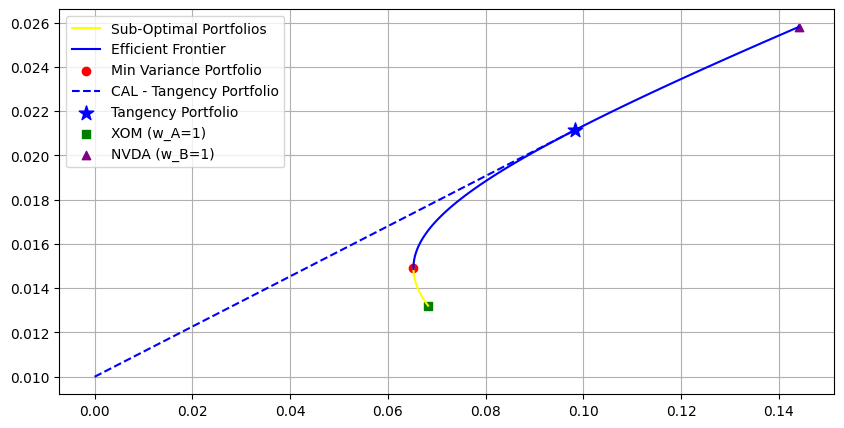

In [29]:
plt.figure(figsize=(10, 5))

w_A_range = np.linspace(0, 1, 100)
expected_returns = w_A_range * mean_A_monthly + (1 - w_A_range) * mean_B_monthly
variances = (
    w_A_range**2 * var_A_monthly
    + (1 - w_A_range)**2 * var_B_monthly
    + 2 * w_A_range * (1 - w_A_range) * cov_AB_monthly
)
std_devs = np.sqrt(variances)


# Plot the CAL
min_var_index = np.argmin(std_devs)

# Plot the CAL
plt.plot(std_devs[min_var_index:], expected_returns[min_var_index:], color="yellow", label="Sub-Optimal Portfolios")
plt.plot(std_devs[:min_var_index+1], expected_returns[:min_var_index+1], color="blue", label="Efficient Frontier")
plt.scatter(
    np.sqrt(min_var_value), expected_return_min_var, color="red", marker="o", label="Min Variance Portfolio"
)
plt.plot([0, std_tangency], [R_f, expected_return_tangency], linestyle="dashed", color="blue", label="CAL - Tangency Portfolio")

plt.scatter(std_tangency, expected_return_tangency, color="blue", marker="*", s=120, label="Tangency Portfolio")
plt.scatter(std_A_monthly, mean_A_monthly, color="green", marker="s", label="XOM (w_A=1)")
plt.scatter(std_B_monthly, mean_B_monthly, color="purple", marker="^", label="NVDA (w_B=1)")


plt.legend()
plt.grid(True)
plt.show()



# LOOKING AT MORE THAN TWO STOCKS

/tmp/ipykernel_22148/3442432202.py:19: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(tickers, start=start_date, end=end_date)["Close"]
[*********************100%***********************]  3 of 3 completed


21-Day Mean Returns:
Ticker
AMX     0.032646
NVDA    0.025807
XOM     0.013212
dtype: float64

21-Day Variances:
Ticker
AMX     0.005006
NVDA    0.020783
XOM     0.004657
dtype: float64

21-Day Standard Deviations:
Ticker
AMX     0.070756
NVDA    0.144162
XOM     0.068240
dtype: float64

Daily Correlation Matrix:
Ticker       AMX      NVDA       XOM
Ticker                              
AMX     1.000000  0.158288  0.226299
NVDA    0.158288  1.000000  0.171376
XOM     0.226299  0.171376  1.000000

21-Day Covariance Matrix:
Ticker       AMX      NVDA       XOM
Ticker                              
AMX     0.005006  0.001615  0.001093
NVDA    0.001615  0.020783  0.001686
XOM     0.001093  0.001686  0.004657


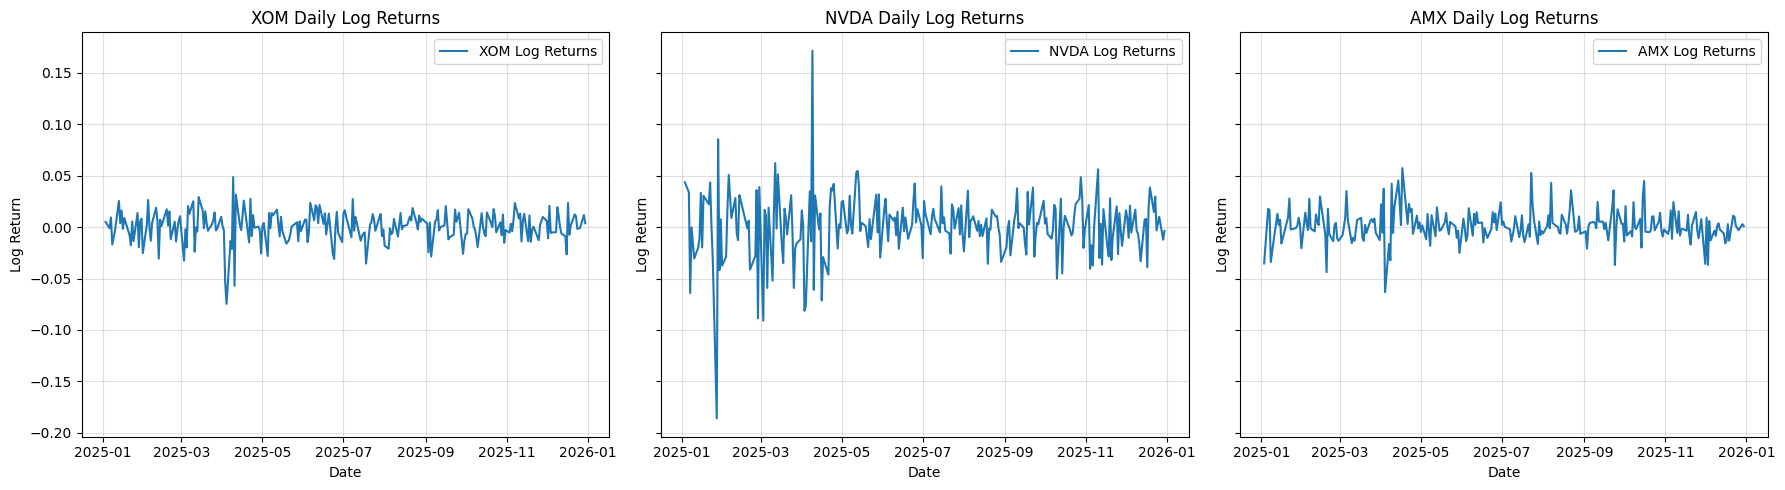

In [30]:
import yfinance as yf
import numpy as np
import pandas as pd
import cvxpy as cp
import matplotlib.pyplot as plt

# -----------------------------
# 1. Download data
# -----------------------------
start_date = "2025-01-01"
end_date = "2025-12-31"

A = "XOM"
B = "NVDA"
C = "AMX"   # If this gives issues, replace with "SPY"

tickers = [A, B, C]

data = yf.download(tickers, start=start_date, end=end_date)["Close"]

# -----------------------------
# 2. Compute daily log-returns
# -----------------------------
returns = np.log(data / data.shift(1)).dropna()

# -----------------------------
# 3. Compute daily summary statistics
# -----------------------------
mean_daily_returns = returns.mean()
var_daily_returns = returns.var()
std_daily_returns = returns.std()

cov_daily = returns.cov()
corr_daily = returns.corr()

# -----------------------------
# 4. Convert to 21-day holding period
# -----------------------------
holding_period = 21

mean_21d_returns = mean_daily_returns * holding_period
var_21d_returns = var_daily_returns * holding_period
std_21d_returns = np.sqrt(holding_period) * std_daily_returns
cov_21d = cov_daily * holding_period

# -----------------------------
# 5. Print results
# -----------------------------
print("21-Day Mean Returns:")
print(mean_21d_returns)

print("\n21-Day Variances:")
print(var_21d_returns)

print("\n21-Day Standard Deviations:")
print(std_21d_returns)

print("\nDaily Correlation Matrix:")
print(corr_daily)

print("\n21-Day Covariance Matrix:")
print(cov_21d)

# -----------------------------
# 6. Plot daily log returns side by side
# -----------------------------
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

for i, ticker in enumerate(tickers):
    axes[i].plot(returns.index, returns[ticker], label=f"{ticker} Log Returns")
    axes[i].set_title(f"{ticker} Daily Log Returns")
    axes[i].set_xlabel("Date")
    axes[i].set_ylabel("Log Return")
    axes[i].legend()
    axes[i].grid(True, alpha=0.4)

plt.tight_layout()
plt.savefig("returns_3assets.png")
plt.show()

# FUNCTION TO IDENTIFY PORTFOLIOS

We define a unique function to:

 - Identify the minimum variance portfolio

 - Identifity the tangency portfolio

 - Plot the full Portfolio Frontier

In [31]:
def compute_efficient_frontier_and_tangency(risk_free_rate, mean_returns, cov_matrix):
    """
    Computes the efficient frontier, identifies the minimum variance portfolio,
    and finds the tangency portfolio by maximizing the Sharpe Ratio.
    """
    target_returns = np.linspace(mean_returns.min(), mean_returns.max(), 50)
    risks = []
    sharpe_ratios = []
    efficient_portfolios = []

    min_var_risk, min_var_return, min_var_weights = None, None, None

    for target_return in target_returns:
        n = len(mean_returns)
        w = cp.Variable(n)

        risk = cp.quad_form(w, cov_matrix)
        objective = cp.Minimize(risk)

        constraints = [
            cp.sum(w) == 1,
            w >= 0,
            mean_returns.values @ w == target_return
        ]

        problem = cp.Problem(objective, constraints)
        problem.solve()

        optimal_weights = w.value
        portfolio_risk = np.sqrt(optimal_weights @ cov_matrix.values @ optimal_weights)

        risks.append(portfolio_risk)
        efficient_portfolios.append(optimal_weights)

        sharpe_ratio = (target_return - risk_free_rate) / portfolio_risk
        sharpe_ratios.append(sharpe_ratio)

        if min_var_risk is None or portfolio_risk < min_var_risk:
            min_var_risk, min_var_return, min_var_weights = portfolio_risk, target_return, optimal_weights

    max_sharpe_idx = np.argmax(sharpe_ratios)
    tangency_weights = efficient_portfolios[max_sharpe_idx]
    tangency_risk = risks[max_sharpe_idx]
    tangency_return = target_returns[max_sharpe_idx]
    tangency_sharpe = sharpe_ratios[max_sharpe_idx]

    return {
        "risks": risks,
        "returns": target_returns,
        "min_var_portfolio": (min_var_risk, min_var_return, min_var_weights),
        "tangency_portfolio": (tangency_risk, tangency_return, tangency_weights, tangency_sharpe),
    }

# CODE TO PLOT THE PORTFOLIO FRONTIER AND THE MINIMUM VARIANCE PORTFOLIO

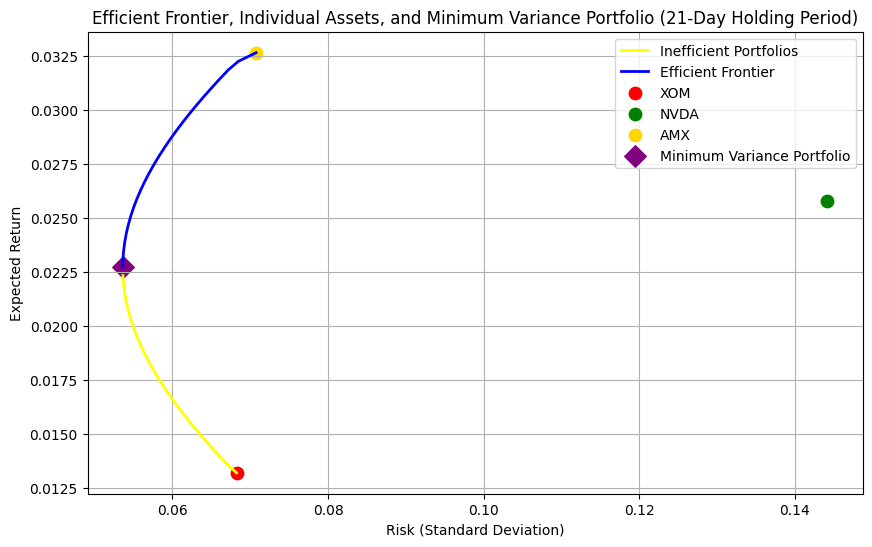


Minimum Variance Portfolio Weights:
Ticker
AMX     0.448308
NVDA    0.064017
XOM     0.487676
Name: Minimum Variance Portfolio Weights, dtype: float64


In [33]:
# Define risk-free return (2% per 21-day holding period, if needed by the function)
risk_free_rate_21d = 0.01

# Compute efficient frontier, minimum variance, and tangency portfolio
frontier_data = compute_efficient_frontier_and_tangency(
    risk_free_rate_21d,
    mean_21d_returns,
    cov_21d
)

# Extract results from frontier_data
risks_21d = np.array(frontier_data["risks"])
returns_21d = np.array(frontier_data["returns"])
min_var_risk, min_var_return, min_var_weights = frontier_data["min_var_portfolio"]

# Simplified Plot: Efficient Frontier with Individual Assets and Minimum Variance Portfolio
plt.figure(figsize=(10, 6))

# Split the efficient frontier:
# yellow = inefficient portfolios, blue = efficient portfolios
below_min_var = returns_21d < min_var_return
above_min_var = returns_21d >= min_var_return

plt.plot(
    risks_21d[below_min_var],
    returns_21d[below_min_var],
    color="yellow",
    label="Inefficient Portfolios",
    linewidth=2
)

plt.plot(
    risks_21d[above_min_var],
    returns_21d[above_min_var],
    color="blue",
    label="Efficient Frontier",
    linewidth=2
)

# Plot individual assets
asset_colors = ["red", "green", "gold"]
for color, ticker in zip(asset_colors, tickers):
    plt.scatter(
        std_21d_returns[ticker],
        mean_21d_returns[ticker],
        color=color,
        label=ticker,
        marker="o",
        s=80
    )

# Highlight the minimum variance portfolio
plt.scatter(
    min_var_risk,
    min_var_return,
    color="purple",
    label="Minimum Variance Portfolio",
    marker="D",
    s=120
)

# Labels and legend
plt.xlabel("Risk (Standard Deviation)")
plt.ylabel("Expected Return")
plt.title("Efficient Frontier, Individual Assets, and Minimum Variance Portfolio (21-Day Holding Period)")
plt.legend()
plt.grid(True)

# Save and show
plt.savefig("frontieri.png")
plt.show()

# Print the weights of the minimum variance portfolio
min_var_weights_df = pd.Series(
    min_var_weights,
    index=mean_21d_returns.index,
    name="Minimum Variance Portfolio Weights"
)

print("\nMinimum Variance Portfolio Weights:")
print(min_var_weights_df)

# IDENTIFYING THE TANGENCY PORTFOLIO

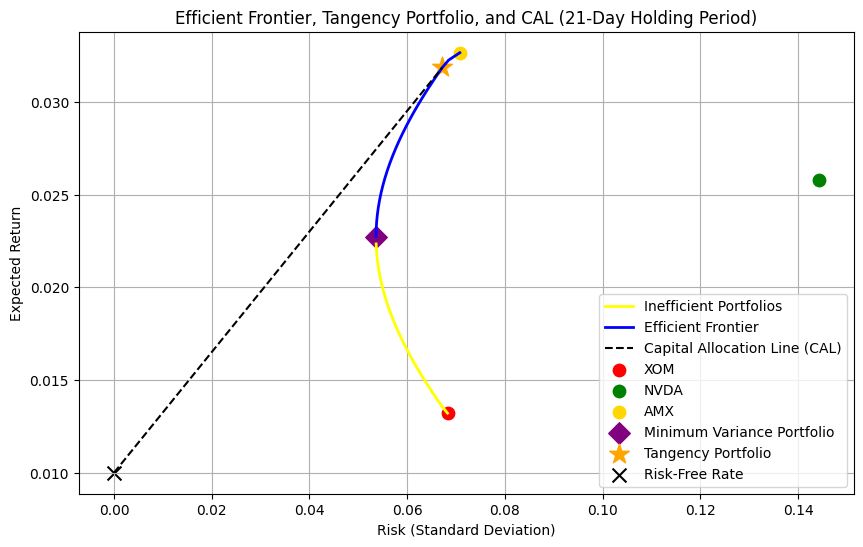


Tangency Portfolio Weights:
Ticker
AMX     0.897785
NVDA    0.094738
XOM     0.007477
Name: Tangency Portfolio Weights, dtype: float64

Sharpe Ratio of Tangency Portfolio: 0.3253
Tangency Portfolio Return: 0.0319
Tangency Portfolio Risk (Std Dev): 0.0672


In [34]:
# Extract results
risks_21d = np.array(frontier_data["risks"])
returns_21d = np.array(frontier_data["returns"])

min_var_risk, min_var_return, min_var_weights = frontier_data["min_var_portfolio"]
tangency_risk, tangency_return, tangency_weights, tangency_sharpe = frontier_data["tangency_portfolio"]

# Plot the efficient frontier with CAL and portfolios
plt.figure(figsize=(10, 6))

# Split the efficient frontier: Yellow for inefficient portfolios, Blue for efficient
below_min_var = returns_21d < min_var_return
above_min_var = returns_21d >= min_var_return

plt.plot(
    risks_21d[below_min_var],
    returns_21d[below_min_var],
    color="yellow",
    label="Inefficient Portfolios",
    linewidth=2
)

plt.plot(
    risks_21d[above_min_var],
    returns_21d[above_min_var],
    color="blue",
    label="Efficient Frontier",
    linewidth=2
)

# Plot Capital Allocation Line (CAL)
cal_x = np.linspace(0, tangency_risk, 100)
cal_y = risk_free_rate_21d + ((tangency_return - risk_free_rate_21d) / tangency_risk) * cal_x
plt.plot(
    cal_x,
    cal_y,
    color="black",
    linestyle="dashed",
    label="Capital Allocation Line (CAL)"
)

# Plot individual assets dynamically
asset_colors = ["red", "green", "gold"]
for color, ticker in zip(asset_colors, tickers):
    plt.scatter(
        std_21d_returns[ticker],
        mean_21d_returns[ticker],
        color=color,
        label=ticker,
        marker="o",
        s=80
    )

# Highlight the minimum variance portfolio
plt.scatter(
    min_var_risk,
    min_var_return,
    color="purple",
    label="Minimum Variance Portfolio",
    marker="D",
    s=120
)

# Highlight the tangency portfolio
plt.scatter(
    tangency_risk,
    tangency_return,
    color="orange",
    label="Tangency Portfolio",
    marker="*",
    s=220
)

# Highlight the risk-free rate
plt.scatter(
    0,
    risk_free_rate_21d,
    color="black",
    label="Risk-Free Rate",
    marker="x",
    s=100
)

# Labels and legend
plt.xlabel("Risk (Standard Deviation)")
plt.ylabel("Expected Return")
plt.title("Efficient Frontier, Tangency Portfolio, and CAL (21-Day Holding Period)")
plt.legend()
plt.grid(True)

# Save and show
plt.savefig("call.png")
plt.show()

# Print Tangency Portfolio Weights and Sharpe Ratio
tangency_weights_df = pd.Series(
    tangency_weights,
    index=mean_21d_returns.index,
    name="Tangency Portfolio Weights"
)

print("\nTangency Portfolio Weights:")
print(tangency_weights_df)

print(f"\nSharpe Ratio of Tangency Portfolio: {tangency_sharpe:.4f}")
print(f"Tangency Portfolio Return: {tangency_return:.4f}")
print(f"Tangency Portfolio Risk (Std Dev): {tangency_risk:.4f}")